Using Colab cache for faster access to the 'rice-image-dataset' dataset.
1. Loading dataset and extracting features...
Dataset created with 200 records.

4. Encoding labels...
5. Splitting dataset and training KNN model...
6. Evaluating the model...

--- Model Evaluation Results ---
Accuracy: 97.50%

Confusion Matrix:
[[21  0]
 [ 1 18]]

Classification Report:
              precision    recall  f1-score   support

     Arborio       0.95      1.00      0.98        21
     Basmati       1.00      0.95      0.97        19

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40

--------------------------------


--- Model Evaluation Results ---
Accuracy: 97.50%

7. Running prediction on a sample image...


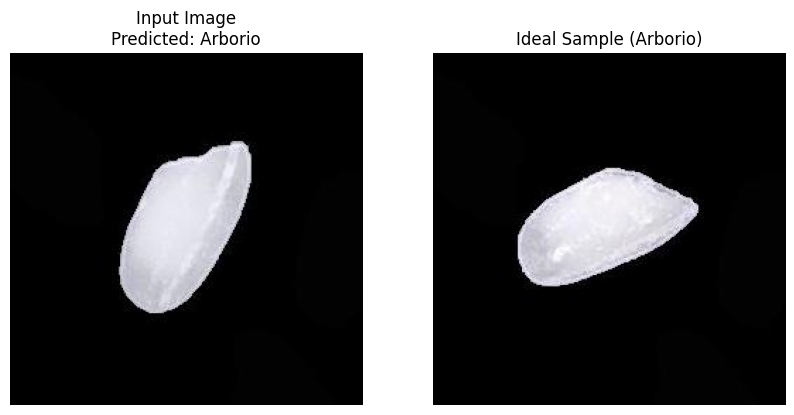

In [3]:
import os
import cv2
import glob
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings


warnings.filterwarnings("ignore")
# ==========================================
# Preprocessing & Feature Extraction
# ==========================================
def extract_features(image_path):
    img = cv2.imread(image_path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None

    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
    compactness = (perimeter ** 2) / area if area > 0 else 0

    eccentricity = 0
    if len(c) >= 5:
        (x, y), (MA, ma), angle = cv2.fitEllipse(c)
        a = ma / 2
        b = MA / 2
        if a > b and a > 0:
            eccentricity = sqrt(1 - (b ** 2) / (a ** 2))

    return [area, perimeter, eccentricity, compactness]

# ==========================================
# Dataset Preparation
# ==========================================
def load_dataset(base_path, classes):
    data = []
    labels = []
    for class_name in classes:
        folder_path = os.path.join(base_path, class_name)
        image_paths = glob.glob(os.path.join(folder_path, "*.jpg"))
        for img_path in image_paths[:100]:
            features = extract_features(img_path)
            if features is not None:
                data.append(features)
                labels.append(class_name)

    columns = ['Area', 'Perimeter', 'Eccentricity', 'Compactness']
    df = pd.DataFrame(data, columns=columns)
    df['Label'] = labels
    return df

# ==========================================
# Prediction and Visualization
# ==========================================
def predict_and_display(image_path, model, label_encoder, ideal_image_paths):
    features = extract_features(image_path)
    if features is None:
        print("Could not extract features.")
        return

    prediction_encoded = model.predict([features])
    predicted_class = label_encoder.inverse_transform(prediction_encoded)[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    input_img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    axes[0].imshow(input_img)
    axes[0].set_title(f"Input Image\nPredicted: {predicted_class}")
    axes[0].axis('off')

    ideal_img_path = ideal_image_paths[predicted_class]
    ideal_img = cv2.cvtColor(cv2.imread(ideal_img_path), cv2.COLOR_BGR2RGB)
    axes[1].imshow(ideal_img)
    axes[1].set_title(f"Ideal Sample ({predicted_class})")
    axes[1].axis('off')
    plt.show()

# ==========================================
# Main Execution Flow
# ==========================================
if __name__ == "__main__":
    print("Downloading dataset from Kaggle...")
    download_path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")
    DATASET_PATH = os.path.join(download_path, "Rice_Image_Dataset")
    if not os.path.exists(DATASET_PATH): DATASET_PATH = download_path

    CLASSES = ["Arborio", "Basmati"]

    print("1. Loading dataset and extracting features...")
    df = load_dataset(DATASET_PATH, CLASSES)
    print(f"Dataset created with {len(df)} records.\n")

    print("4. Encoding labels...")
    le = LabelEncoder()
    y = le.fit_transform(df['Label'])


    X = df[['Area', 'Perimeter', 'Eccentricity', 'Compactness']].values

    print("5. Splitting dataset and training KNN model...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    print("6. Evaluating the model...")
    y_pred = knn.predict(X_test)

    print("\n--- Model Evaluation Results ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=CLASSES))
    print("-" * 32 + "\n")

    print("\n--- Model Evaluation Results ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

    print("7. Running prediction on a sample image...")
    sample_test_path = glob.glob(os.path.join(DATASET_PATH, CLASSES[0], "*.jpg"))[0]
    ideal_images = {
        CLASSES[0]: glob.glob(os.path.join(DATASET_PATH, CLASSES[0], "*.jpg"))[1],
        CLASSES[1]: glob.glob(os.path.join(DATASET_PATH, CLASSES[1], "*.jpg"))[1]
    }

    predict_and_display(sample_test_path, knn, le, ideal_images)